# Network Traffic Flowlet Analysis
Visualizations of the MongoDB `networks_project.captures` collection. Each capture stores flowlets parsed at different inter-packet-time thresholds (0.05 s, 0.1 s, 0.2 s).

In [1]:
# =====================================================================
# Paper-style helpers (sized for IMC two-column PDF)
# =====================================================================
# Why this cell exists
# --------------------
# The original notebook used the seaborn "crest" palette (a sequential
# blue->teal ramp). Crest is built for *ordered* data, so when it is mapped
# onto unordered categories (LLM vs non-LLM, CHATGPT vs CLAUDE vs GEMINI),
# adjacent categories receive nearly identical colors. That is what makes
# the three lines in Figure 3 of the screenshot collapse into one band.
#
# We replace that with a categorical, colorblind-safe encoding scheme
# (Okabe & Ito 2008), and we add a *redundant* visual channel to every
# figure so the encoding survives:
#   1. deuteranopia / protanopia / tritanopia,
#   2. greyscale printing,
#   3. shrinkage to a 3-inch paper column.
#
# Specifically:
#   - bars/boxes    -> color + hatch pattern
#   - line plots    -> color + linestyle + marker shape
#   - scatter plots -> color + marker shape
#   - heatmaps      -> cividis (perceptually uniform, CVD-optimized)
# =====================================================================

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Okabe & Ito categorical palette (8 colors, CVD-safe) ----
# Order chosen so the first 2-3 entries (the common case) have the largest
# luminance separation: dark blue -> orange -> bluish green.
OKABE_ITO = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#CC79A7",  # reddish purple
    "#56B4E9",  # sky blue
    "#D55E00",  # vermillion
    "#F0E442",  # yellow
    "#000000",  # black
]

# ---- Redundant-encoding tables ----
# Hatch density tuned to remain visible at 300 dpi when the figure is
# downscaled to ~3 in. First slot is empty so the "primary" series stays
# visually clean.
HATCHES = ["", "///", "xxx", "...", "|||", "+++", "OO", "\\\\\\"]

# Line styles distinguishable at 1.0-1.4 pt linewidth.
LINESTYLES = [
    "-",                       # solid
    (0, (5, 2)),               # dashed
    (0, (1, 1.5)),             # dotted
    (0, (3, 1.5, 1, 1.5)),     # dash-dot
    (0, (5, 1, 1, 1, 1, 1)),   # dash-dot-dot
    (0, (4, 1, 4, 1, 1, 1)),
    (0, (1, 0.5)),
    (0, (6, 1)),
]

# Marker shapes that stay distinct at 4-5 pt.
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "<"]

# ---- Figure size presets (inches) ----
# ACM 2-column format: single column ~= 3.33 in, full text width ~= 7.0 in.
# Heights chosen so multi-panel rows do not collide with axis labels.
FIG_FULL          = (7.0, 2.4)   # full width, 1 row of 3 panels
FIG_FULL_TALL     = (7.0, 4.6)   # full width, 2 rows of 3
FIG_FULL_2x2      = (7.0, 5.0)   # full width, 2x2 grid
FIG_HALF          = (3.4, 2.6)   # single column, single panel
FIG_FULL_2PANEL   = (7.0, 2.6)   # full width, 1x2 panels
FIG_FULL_SINGLE   = (7.0, 2.6)   # full width, single panel (e.g. wide bars)

# ---- Apply paper-ready rcParams ----
def set_paper_style():
    sns.set_theme(style="whitegrid", palette=OKABE_ITO)
    mpl.rcParams.update({
        # Fonts: target ~9 pt body in the rendered PDF. Because we size
        # figures at their final paper dimensions, source pt = printed pt.
        "font.size":              9,
        "axes.titlesize":         10,
        "axes.labelsize":         9,
        "xtick.labelsize":        8,
        "ytick.labelsize":        8,
        "legend.fontsize":        8,
        "legend.title_fontsize":  8,
        "figure.titlesize":       10,
        # Embed Type-42 fonts so reviewers can search/select text in the PDF.
        "font.family":            "sans-serif",
        "pdf.fonttype":           42,
        "ps.fonttype":            42,
        # Sharp rendering.
        "figure.dpi":             120,
        "savefig.dpi":            300,
        "savefig.bbox":           "tight",
        "savefig.pad_inches":     0.02,
        # Cleaner axes.
        "axes.spines.top":        False,
        "axes.spines.right":      False,
        "axes.linewidth":         0.7,
        "axes.titlepad":          4.0,
        "axes.labelpad":          2.5,
        "axes.grid":              True,
        "grid.linewidth":         0.4,
        "grid.alpha":             0.5,
        # Lines / patches with a thin dark outline so hatches read clearly.
        "lines.linewidth":        1.4,
        "lines.markersize":       4.5,
        "patch.linewidth":        0.6,
        "patch.edgecolor":        "#222222",
        "hatch.linewidth":        0.45,
        "hatch.color":            "#222222",
        "xtick.major.size":       2.5,
        "ytick.major.size":       2.5,
        "xtick.major.width":      0.6,
        "ytick.major.width":      0.6,
        "legend.frameon":         True,
        "legend.framealpha":      0.9,
        "legend.edgecolor":       "#cccccc",
        "legend.borderpad":       0.3,
        "legend.handletextpad":   0.5,
        "legend.columnspacing":   1.0,
    })

# ---- Helper: hatch every patch on an axis by face-color group ----
# Uses face color as the grouping key, which is robust to the seaborn
# patch-ordering changes between v0.12 and v0.13.
def hatch_by_facecolor(ax, hatches=None):
    hatches = list(hatches if hatches is not None else HATCHES)
    color_to_hatch, next_idx = {}, 0
    for patch in ax.patches:
        try:
            color = tuple(round(c, 4) for c in patch.get_facecolor())
        except Exception:
            continue
        if color not in color_to_hatch:
            color_to_hatch[color] = hatches[next_idx % len(hatches)]
            next_idx += 1
        patch.set_hatch(color_to_hatch[color])
    leg = ax.get_legend()
    if leg is not None:
        handles = getattr(leg, "legend_handles", None) or leg.legendHandles
        for h in handles:
            try:
                color = tuple(round(c, 4) for c in h.get_facecolor())
                if color in color_to_hatch:
                    h.set_hatch(color_to_hatch[color])
            except Exception:
                pass

# ---- Helper: apply linestyle + marker by hue group to a line plot ----
def style_lines(ax):
    visible = [ln for ln in ax.lines
               if not (ln.get_label() or "").startswith("_")]
    for i, line in enumerate(visible):
        line.set_linestyle(LINESTYLES[i % len(LINESTYLES)])
        line.set_marker(MARKERS[i % len(MARKERS)])
        line.set_markersize(4.5)
        line.set_markeredgewidth(0.5)
        line.set_markeredgecolor("white")
    leg = ax.get_legend()
    if leg is not None:
        handles = getattr(leg, "legend_handles", None) or leg.legendHandles
        for i, h in enumerate(handles):
            try:
                h.set_linestyle(LINESTYLES[i % len(LINESTYLES)])
                h.set_marker(MARKERS[i % len(MARKERS)])
                h.set_markersize(4.5)
                h.set_markeredgecolor("white")
            except Exception:
                pass

def cb_palette(n):
    return [OKABE_ITO[i % len(OKABE_ITO)] for i in range(n)]

set_paper_style()


In [2]:
import re, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
set_paper_style()  # already called above; safe to re-run

# ── Find the newest snapshot under data-pipeline/data/snapshots ──
snapshots_root = Path("../data-pipeline/data/snapshots")
snapshot_dirs = sorted(snapshots_root.glob("snapshot_*"), reverse=True)
if not snapshot_dirs:
    raise FileNotFoundError(f"No snapshots found in {snapshots_root.resolve()}")
snapshot_dir = snapshot_dirs[0]
captures_dir = snapshot_dir / "captures"
print(f"Using snapshot: {snapshot_dir.name}")

# ── Load every capture JSON and flatten flowlets into one DataFrame ──
rows = []
capture_files = list(captures_dir.glob("*.json"))
for fpath in capture_files:
    with open(fpath, "r", encoding="utf-8") as f:
        doc = json.load(f)

    cap_id = str(doc.get("_id", fpath.stem))
    file_path = doc.get("file_path", cap_id)

    m = re.search(r"_(\d+\.?\d*)$", file_path)
    threshold = doc.get("threshold")
    base_name = file_path[:m.start()] if m else file_path

    for fl in doc.get("flowlets") or []:
        fk = fl.get("flow_key", {})
        rows.append({
            "capture_id":   cap_id,
            "base_capture":  base_name,
            "threshold":     threshold,
            "file_path":     file_path,
            "traffic_class": fl.get("traffic_class"),
            "llm_name":      fl.get("llm_name"),
            "outgoing":      fl.get("outgoing"),
            "direction_encoded": fl.get("direction_encoded", 0),
            "flowlet_id":    fl.get("flowlet_id"),
            "duration":      fl.get("duration", 0),
            "packet_count":  fl.get("packet_count", 0),
            "total_bytes":   fl.get("total_bytes", 0),
            "packet_size_mean": fl.get("packet_size_mean"),
            "packet_size_std":  fl.get("packet_size_std"),
            "inter_packet_time_mean": fl.get("inter_packet_time_mean"),
            "inter_packet_time_std":  fl.get("inter_packet_time_std"),
            "model_llm_prediction":   fl.get("model_llm_prediction"),
            "model_llm_confidence":   fl.get("model_llm_confidence"),
            "ground_truth_llm":       fl.get("ground_truth_llm"),
            "src_ip":   fk.get("src_ip"),
            "dst_ip":   fk.get("dst_ip"),
            "protocol": fk.get("protocol"),
        })

df = pd.DataFrame(rows)
print(f"Loaded {len(df):,} flowlets from {len(capture_files)} captures")
df.head()

Using snapshot: snapshot_20260427_103527
Loaded 674,852 flowlets from 129 captures


,capture_id,base_capture,threshold,file_path,traffic_class,llm_name,outgoing,direction_encoded,flowlet_id,duration,...,packet_size_mean,packet_size_std,inter_packet_time_mean,inter_packet_time_std,model_llm_prediction,model_llm_confidence,ground_truth_llm,src_ip,dst_ip,protocol
0,gavin_llm_april_7_part6_ipv6_0.2,gavin_llm_april_7_part6_ipv6,0.2,gavin_llm_april_7_part6_ipv6_0.2,llm,GEMINI,False,-1,1,0.106957,...,530.350000,569.131867,0.005629,0.009059,None,None,None,2601:5cf:407e:8160:7de3:77e4:f167:1d7,2001:4860:4826:7700::,17
1,gavin_llm_april_7_part6_ipv6_0.2,gavin_llm_april_7_part6_ipv6,0.2,gavin_llm_april_7_part6_ipv6_0.2,llm,GEMINI,False,-1,2,0.251183,...,181.000000,348.285411,0.022835,0.022557,None,None,None,2601:5cf:407e:8160:7de3:77e4:f167:1d7,2001:4860:4826:7700::,17
2,gavin_llm_april_7_part6_ipv6_0.2,gavin_llm_april_7_part6_ipv6,0.2,gavin_llm_april_7_part6_ipv6_0.2,llm,GEMINI,False,-1,1,0.132184,...,611.379310,545.761814,0.004721,0.009738,None,None,None,2601:5cf:407e:8160:7de3:77e4:f167:1d7,2607:f8b0:4004:c1d::65,17
3,gavin_llm_april_7_part6_ipv6_0.2,gavin_llm_april_7_part6_ipv6,0.2,gavin_llm_april_7_part6_ipv6_0.2,llm,GEMINI,False,-1,1,0.127705,...,315.222222,501.075791,0.004912,0.010087,None,None,None,2601:5cf:407e:8160:7de3:77e4:f167:1d7,2a04:4e42:78::347,6
4,gavin_llm_april_7_part6_ipv6_0.2,gavin_llm_april_7_part6_ipv6,0.2,gavin_llm_april_7_part6_ipv6_0.2,llm,GEMINI,False,-1,1,0.086760,...,566.000000,586.536668,0.004566,0.009989,None,None,None,2601:5cf:407e:8160:7de3:77e4:f167:1d7,2607:f8b0:4004:c21::8a,6


## Dataset Overview

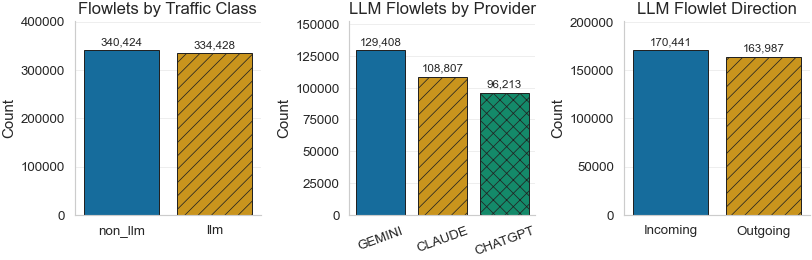

In [3]:
# 1x3 bar panel, full-text width.
# Each panel is unordered categorical, so we use the categorical Okabe-Ito
# palette and add a unique hatch per bar via hatch_by_facecolor().
#
# NOTE: with `hue=x` (the seaborn 0.14 forward-compatible pattern), each
# hue level becomes its own container, so we must iterate `ax.containers`
# rather than indexing `containers[0]`.
fig, axes = plt.subplots(1, 3, figsize=FIG_FULL)

def _label_all(ax, fontsize=7, padding=2):
    for c in ax.containers:
        ax.bar_label(c, fmt="{:,.0f}", fontsize=fontsize, padding=padding)

def _add_headroom(ax, factor=1.18):
    heights = [b.get_height() for c in ax.containers for b in c]
    if heights:
        ax.set_ylim(0, max(heights) * factor)

# 1. Traffic class split
class_counts = df["traffic_class"].value_counts()
sns.barplot(
    x=class_counts.index, y=class_counts.values,
    hue=class_counts.index, palette=cb_palette(len(class_counts)),
    legend=False, ax=axes[0],
)
axes[0].set_title("Flowlets by Traffic Class")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("")
_label_all(axes[0])
hatch_by_facecolor(axes[0])

# 2. LLM provider breakdown
llm_df = df[df["traffic_class"] == "llm"]
if not llm_df.empty:
    llm_counts = llm_df["llm_name"].value_counts()
    sns.barplot(
        x=llm_counts.index, y=llm_counts.values,
        hue=llm_counts.index, palette=cb_palette(len(llm_counts)),
        legend=False, ax=axes[1],
    )
    axes[1].set_title("LLM Flowlets by Provider")
    axes[1].set_ylabel("Count")
    axes[1].set_xlabel("")
    _label_all(axes[1])
    axes[1].tick_params(axis="x", rotation=20)
    hatch_by_facecolor(axes[1])
else:
    axes[1].set_title("LLM Flowlets by Provider (no data)")

# 3. Direction split for LLM traffic
if not llm_df.empty:
    dir_labels = llm_df["outgoing"].map({True: "Outgoing", False: "Incoming", None: "Unknown"})
    dir_counts = dir_labels.value_counts()
    sns.barplot(
        x=dir_counts.index, y=dir_counts.values,
        hue=dir_counts.index, palette=cb_palette(len(dir_counts)),
        legend=False, ax=axes[2],
    )
    axes[2].set_title("LLM Flowlet Direction")
    axes[2].set_ylabel("Count")
    axes[2].set_xlabel("")
    _label_all(axes[2])
    hatch_by_facecolor(axes[2])
else:
    axes[2].set_title("LLM Flowlet Direction (no data)")

for ax in axes:
    _add_headroom(ax)

plt.tight_layout()
plt.show()


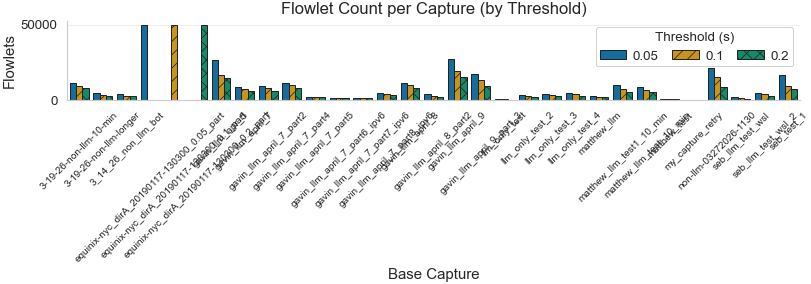

In [4]:
# Bars across many captures, one bar per (capture, threshold) cell.
# Threshold is *ordered* (0.05 < 0.1 < 0.2), so it is reasonable to use
# Okabe-Ito's first three colors in monotonic luminance order, AND we still
# add hatching so the three thresholds are distinguishable in greyscale.
cap_counts = (
    df.groupby(["base_capture", "threshold"])
      .size()
      .reset_index(name="flowlet_count")
)

fig, ax = plt.subplots(figsize=FIG_FULL_SINGLE)
sns.barplot(
    data=cap_counts, x="base_capture", y="flowlet_count",
    hue="threshold", palette=cb_palette(cap_counts["threshold"].nunique()),
    ax=ax,
)
ax.set_title("Flowlet Count per Capture (by Threshold)")
ax.set_ylabel("Flowlets")
ax.set_xlabel("Base Capture")
ax.tick_params(axis="x", rotation=45, labelsize=6)
ax.legend(title="Threshold (s)", loc="upper right", ncol=3)
hatch_by_facecolor(ax)
plt.tight_layout()
plt.show()


## Threshold Impact Analysis
How does the inter-packet-time threshold affect flowlet characteristics? Captures are run at 0.05 s, 0.1 s, and 0.2 s — a larger threshold merges more packets into fewer, longer flowlets.

  threshold_str  flowlet_count  flowlet_pct
0        0.05 s         269419    41.018696
1         0.1 s         213001    32.429128
2         0.2 s         174400    26.552176


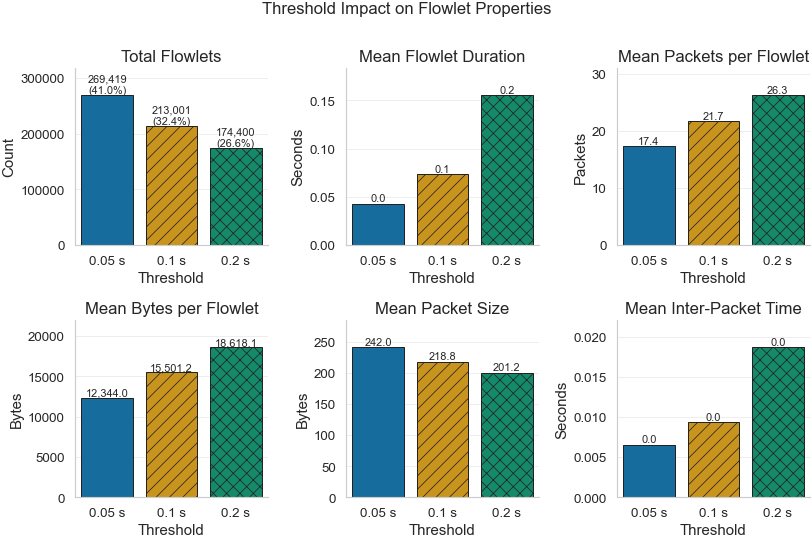

In [5]:
# 2x3 bar panel summarising threshold impact on flowlet properties.
thr_df = df.dropna(subset=["threshold"]).copy()
thr_df["threshold_str"] = thr_df["threshold"].apply(lambda t: f"{t:g} s")

fig, axes = plt.subplots(2, 3, figsize=FIG_FULL_TALL)

agg = (
    thr_df.groupby("threshold_str")
          .agg(
              flowlet_count=("flowlet_id", "count"),
              mean_duration=("duration", "mean"),
              mean_packet_count=("packet_count", "mean"),
              mean_total_bytes=("total_bytes", "mean"),
              mean_pkt_size=("packet_size_mean", "mean"),
              mean_ipt=("inter_packet_time_mean", "mean"),
          )
          .reset_index()
)
agg = agg.sort_values(
    by="threshold_str",
    key=lambda x: x.str.replace(" s", "").astype(float),
)

total_flowlets = agg["flowlet_count"].sum()
agg["flowlet_pct"] = 100 * agg["flowlet_count"] / total_flowlets
print(agg[["threshold_str", "flowlet_count", "flowlet_pct"]])

palette = cb_palette(len(agg))

# ---- Row 1 ----
for ax, col, title, ylabel in zip(
    axes[0],
    ["flowlet_count", "mean_duration", "mean_packet_count"],
    ["Total Flowlets", "Mean Flowlet Duration", "Mean Packets per Flowlet"],
    ["Count", "Seconds", "Packets"],
):
    sns.barplot(
        data=agg, x="threshold_str", y=col,
        hue="threshold_str", palette=palette, legend=False, ax=ax,
    )
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Threshold")
    ax.set_ylim(0, agg[col].max() * 1.18)
    if col == "flowlet_count":
        for bar, c, p in zip(ax.patches, agg["flowlet_count"], agg["flowlet_pct"]):
            ax.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{c:,.0f}\n({p:.1f}%)",
                ha="center", va="bottom", fontsize=6.5,
            )
    else:
        for bar in ax.patches:
            ax.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{bar.get_height():,.1f}",
                ha="center", va="bottom", fontsize=6.5,
            )
    hatch_by_facecolor(ax)

# ---- Row 2 ----
for ax, col, title, ylabel in zip(
    axes[1],
    ["mean_total_bytes", "mean_pkt_size", "mean_ipt"],
    ["Mean Bytes per Flowlet", "Mean Packet Size", "Mean Inter-Packet Time"],
    ["Bytes", "Bytes", "Seconds"],
):
    sns.barplot(
        data=agg, x="threshold_str", y=col,
        hue="threshold_str", palette=palette, legend=False, ax=ax,
    )
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Threshold")
    ax.set_ylim(0, agg[col].max() * 1.18)
    for bar in ax.patches:
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{bar.get_height():,.1f}",
            ha="center", va="bottom", fontsize=6.5,
        )
    hatch_by_facecolor(ax)

plt.suptitle("Threshold Impact on Flowlet Properties", y=1.0)
plt.tight_layout()
plt.show()


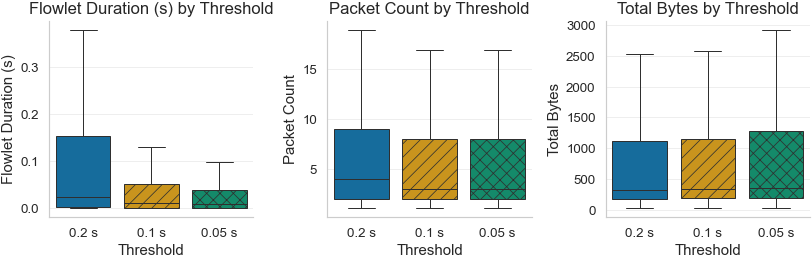

In [6]:
# 1x3 boxplot panel: distribution shifts across thresholds.
# Categorical (thresholds), so each box gets a distinct color + hatch.
fig, axes = plt.subplots(1, 3, figsize=FIG_FULL)

palette = cb_palette(thr_df["threshold_str"].nunique())

for ax, col, title in zip(
    axes,
    ["duration", "packet_count", "total_bytes"],
    ["Flowlet Duration (s)", "Packet Count", "Total Bytes"],
):
    sns.boxplot(
        data=thr_df, x="threshold_str", y=col,
        hue="threshold_str", palette=palette, legend=False,
        showfliers=False, linewidth=0.6, ax=ax,
    )
    ax.set_title(f"{title} by Threshold")
    ax.set_xlabel("Threshold")
    ax.set_ylabel(title)
    hatch_by_facecolor(ax)

plt.tight_layout()
plt.show()


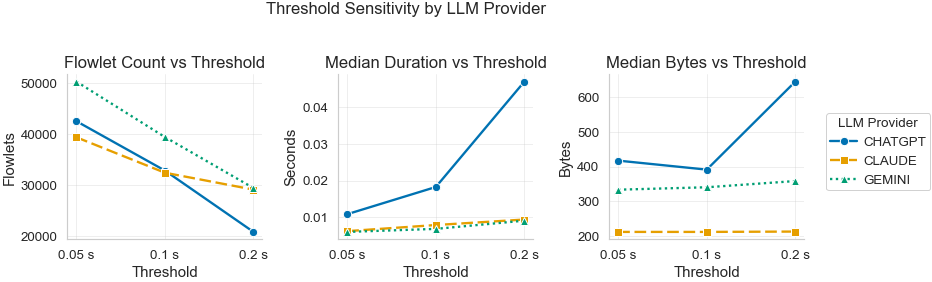

In [21]:
import matplotlib.lines as mlines
import matplotlib.colors as mcolors

# Line plot with hue = LLM provider. Each provider gets a unique
# color + linestyle + marker so the three lines remain distinguishable
# in greyscale and at small print sizes. Styling is done inline (not via
# style_lines) so it's robust to Jupyter caching paper_style.py — no
# need to restart the kernel after editing the helper module.
llm_thr = thr_df[(thr_df["traffic_class"] == "llm") & (thr_df["llm_name"].notna())].copy()

if llm_thr.empty:
    print("No LLM flowlets with llm_name available for threshold-by-provider analysis.")
else:
    prov = (
        llm_thr.groupby(["threshold_str", "llm_name"])
              .agg(
                  flowlet_count=("flowlet_id", "count"),
                  median_duration=("duration", "median"),
                  median_packets=("packet_count", "median"),
                  median_bytes=("total_bytes", "median"),
              )
              .reset_index()
    )

    # Fixed provider order so colors/styles are stable across runs and panels.
    providers = sorted(prov["llm_name"].unique())
    n_llm = len(providers)
    palette = cb_palette(n_llm)

    # Per-provider style: (color, linestyle, marker). Used both to restyle
    # the data lines and to build the side legend manually.
    style_map = {
        p: (palette[i], LINESTYLES[i], MARKERS[i])
        for i, p in enumerate(providers)
    }

    fig, axes = plt.subplots(1, 3, figsize=FIG_FULL)

    panel_specs = [
        ("flowlet_count",   "Flowlet Count vs Threshold",   "Flowlets"),
        ("median_duration", "Median Duration vs Threshold", "Seconds"),
        ("median_bytes",    "Median Bytes vs Threshold",    "Bytes"),
    ]

    for ax, (ycol, title, ylabel) in zip(axes, panel_specs):
        sns.lineplot(
            data=prov, x="threshold_str", y=ycol,
            hue="llm_name", hue_order=providers,
            palette=palette, marker="o", ax=ax,
        )
        ax.set_title(title)
        ax.set_xlabel("Threshold")
        ax.set_ylabel(ylabel)

        # Restyle the actual data lines (those with data points). Match
        # them to providers by exact color hex — robust to seaborn's
        # internal label conventions across versions.
        for line in ax.lines:
            if len(line.get_xdata()) == 0:
                continue  # zero-point legend proxy
            line_hex = mcolors.to_hex(line.get_color())
            for _, (col, ls, mk) in style_map.items():
                if mcolors.to_hex(col) == line_hex:
                    line.set_linestyle(ls)
                    line.set_marker(mk)
                    line.set_markersize(5)
                    line.set_markeredgewidth(0.6)
                    line.set_markeredgecolor("white")
                    break

        # Strip per-panel legends; one shared legend goes on the right.
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

    # Build the side legend from explicit handles so it can never disagree
    # with the lines.
    handles = [
        mlines.Line2D(
            [], [], color=col, linestyle=ls, marker=mk,
            markersize=5, markeredgewidth=0.6, markeredgecolor="white",
            label=p,
        )
        for p, (col, ls, mk) in style_map.items()
    ]
    fig.legend(
        handles=handles, title="LLM Provider",
        loc="center left", bbox_to_anchor=(1.0, 0.5),
        frameon=True, borderaxespad=0,
    )

    plt.suptitle("Threshold Sensitivity by LLM Provider", y=1.02)
    plt.tight_layout()
    plt.show()

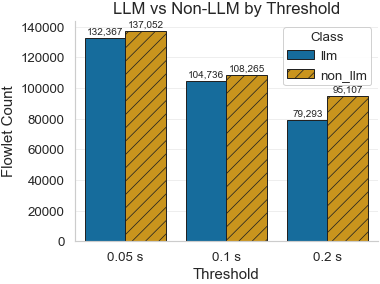

In [22]:
# Grouped bars: LLM vs non-LLM at each threshold. Single column.
class_thr = (
    thr_df.groupby(["threshold_str", "traffic_class"])
          .size()
          .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=FIG_HALF)
sns.barplot(
    data=class_thr, x="threshold_str", y="count",
    hue="traffic_class", palette=cb_palette(class_thr["traffic_class"].nunique()),
    ax=ax,
)
ax.set_title("LLM vs Non-LLM by Threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Flowlet Count")
ax.legend(title="Class", loc="upper right")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", fontsize=6, padding=1)
hatch_by_facecolor(ax)
plt.tight_layout()
plt.show()


## LLM vs Non-LLM Feature Distributions
Comparing the statistical signatures of LLM and non-LLM traffic.

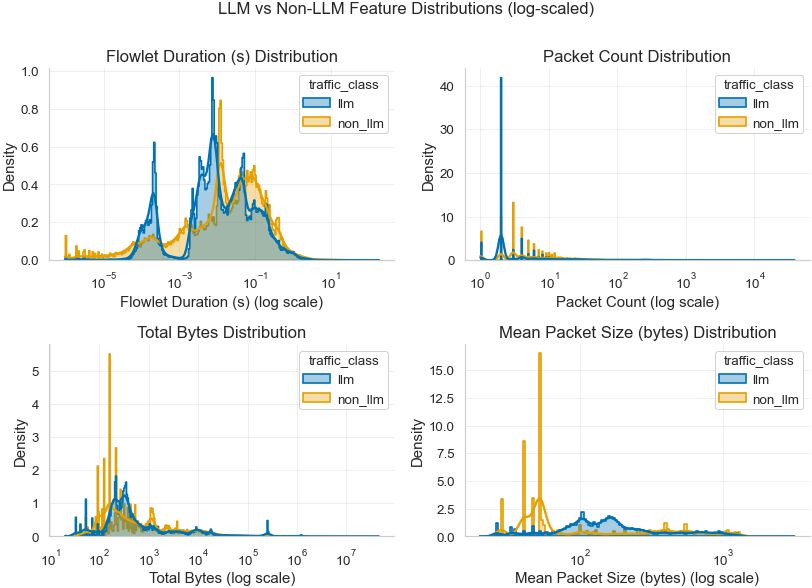

In [23]:
# 2x2 histogram panel. Histograms with hue use stacked transparent fills,
# which are not amenable to hatching (the underlying matplotlib object is
# a PolyCollection, not a Patch). We therefore rely on the strong
# luminance contrast of Okabe-Ito blue vs. orange, plus the KDE outline,
# plus stepped edges, to give two redundant cues besides color.
fig, axes = plt.subplots(2, 2, figsize=FIG_FULL_2x2)

features = [
    ("duration",         "Flowlet Duration (s)"),
    ("packet_count",     "Packet Count"),
    ("total_bytes",      "Total Bytes"),
    ("packet_size_mean", "Mean Packet Size (bytes)"),
]

palette = cb_palette(df["traffic_class"].nunique())

for ax, (col, label) in zip(axes.flat, features):
    subset = df[[col, "traffic_class"]].copy()
    subset = subset.replace([np.inf, -np.inf], np.nan).dropna(subset=[col, "traffic_class"])
    subset = subset[subset[col] > 0]

    sns.histplot(
        data=subset, x=col, hue="traffic_class",
        palette=palette, kde=True, stat="density",
        common_norm=False, log_scale=True,
        element="step", linewidth=1.0, alpha=0.35, ax=ax,
    )
    ax.set_title(f"{label} Distribution")
    ax.set_xlabel(f"{label} (log scale)")

plt.suptitle("LLM vs Non-LLM Feature Distributions (log-scaled)", y=1.0)
plt.tight_layout()
plt.show()


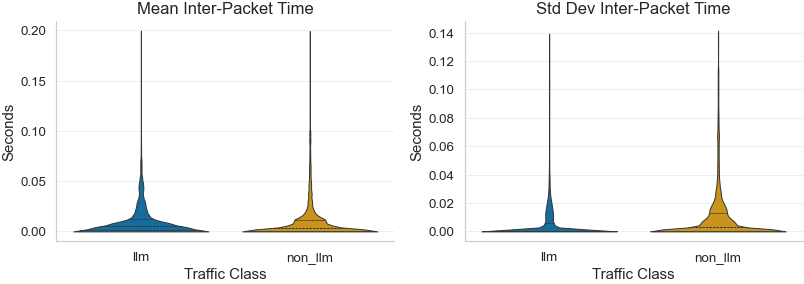

In [24]:
# 1x2 violin panel. Seaborn violins are PolyCollections, so we cannot hatch
# them. The redundant encoding here is: Okabe-Ito high-contrast colors,
# inner quartile lines, and the violin shape itself (which differs between
# classes when they have different distributions).
fig, axes = plt.subplots(1, 2, figsize=FIG_FULL_2PANEL)

palette = cb_palette(df["traffic_class"].nunique())

for ax, col, title in zip(
    axes,
    ["inter_packet_time_mean", "inter_packet_time_std"],
    ["Mean Inter-Packet Time", "Std Dev Inter-Packet Time"],
):
    subset = df.dropna(subset=[col])
    sns.violinplot(
        data=subset, x="traffic_class", y=col,
        hue="traffic_class", palette=palette, legend=False,
        inner="quartile", cut=0, linewidth=0.6, ax=ax,
    )
    ax.set_title(title)
    ax.set_ylabel("Seconds")
    ax.set_xlabel("Traffic Class")

plt.tight_layout()
plt.show()


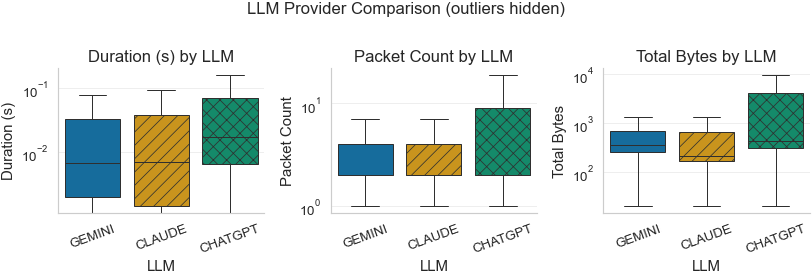

In [25]:
# 1x3 boxplot panel: per-LLM-provider comparison.
if not llm_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=FIG_FULL)
    palette = cb_palette(llm_df["llm_name"].nunique())

    for ax, col, title in zip(
        axes,
        ["duration", "packet_count", "total_bytes"],
        ["Duration (s)", "Packet Count", "Total Bytes"],
    ):
        sns.boxplot(
            data=llm_df, x="llm_name", y=col,
            hue="llm_name", palette=palette, legend=False,
            showfliers=False, linewidth=0.6, ax=ax,
        )
        ax.set_title(f"{title} by LLM")
        ax.set_xlabel("LLM")
        ax.set_yscale("log")
        ax.set_ylabel(title)
        ax.tick_params(axis="x", rotation=20)
        hatch_by_facecolor(ax)

    plt.suptitle("LLM Provider Comparison (outliers hidden)", y=1.0)
    plt.tight_layout()
    plt.show()
else:
    print("No LLM flowlets to compare across providers.")


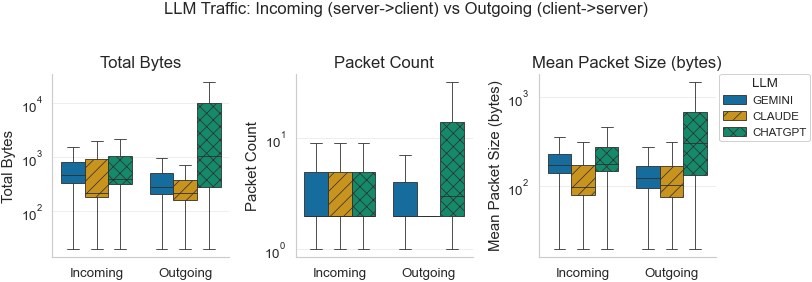

In [26]:
# 1x3 boxplot panel: incoming vs outgoing characteristics, grouped by LLM.
# Each LLM gets its own color + hatch via hatch_by_facecolor.
if not llm_df.empty:
    dir_df = llm_df.copy()
    dir_df["direction"] = dir_df["outgoing"].map({True: "Outgoing", False: "Incoming"})
    dir_df = dir_df.dropna(subset=["direction"])

    palette = cb_palette(dir_df["llm_name"].nunique())

    fig, axes = plt.subplots(1, 3, figsize=FIG_FULL)
    for ax, col, title in zip(
        axes,
        ["total_bytes", "packet_count", "packet_size_mean"],
        ["Total Bytes", "Packet Count", "Mean Packet Size (bytes)"],
    ):
        sns.boxplot(
            data=dir_df, x="direction", y=col,
            hue="llm_name", palette=palette,
            showfliers=False, linewidth=0.5, ax=ax,
        )
        ax.set_title(f"{title}")
        ax.set_yscale("log")
        ax.set_ylabel(title)
        ax.set_xlabel("")
        hatch_by_facecolor(ax)

    # One shared legend on the rightmost axis.
    for ax in axes[:-1]:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()
    axes[-1].legend(title="LLM", bbox_to_anchor=(1.02, 1),
                    loc="upper left", borderaxespad=0, fontsize=7)

    plt.suptitle("LLM Traffic: Incoming (server->client) vs Outgoing (client->server)", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No LLM direction data.")


## Feature Correlations & Advanced Analysis

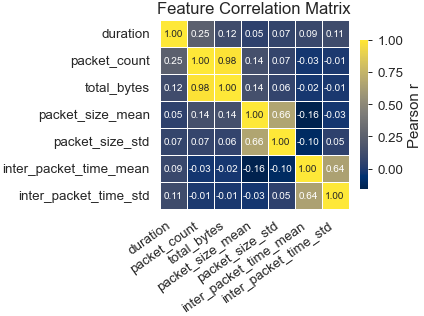

In [27]:
# Correlation heatmap. We replace "crest" with cividis: cividis is a
# perceptually uniform sequential colormap that was specifically designed
# to be readable for viewers with red-green color vision deficiency.
# (crest is also CVD-safe, but cividis is the published-paper standard.)
numeric_cols = [
    "duration", "packet_count", "total_bytes",
    "packet_size_mean", "packet_size_std",
    "inter_packet_time_mean", "inter_packet_time_std",
]
corr = df[numeric_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(3.6, 3.0))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="cividis",
    square=True, linewidths=0.4, annot_kws={"size": 6},
    cbar_kws={"shrink": 0.7, "label": "Pearson r"}, ax=ax,
)
ax.set_title("Feature Correlation Matrix")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
plt.tight_layout()
plt.show()


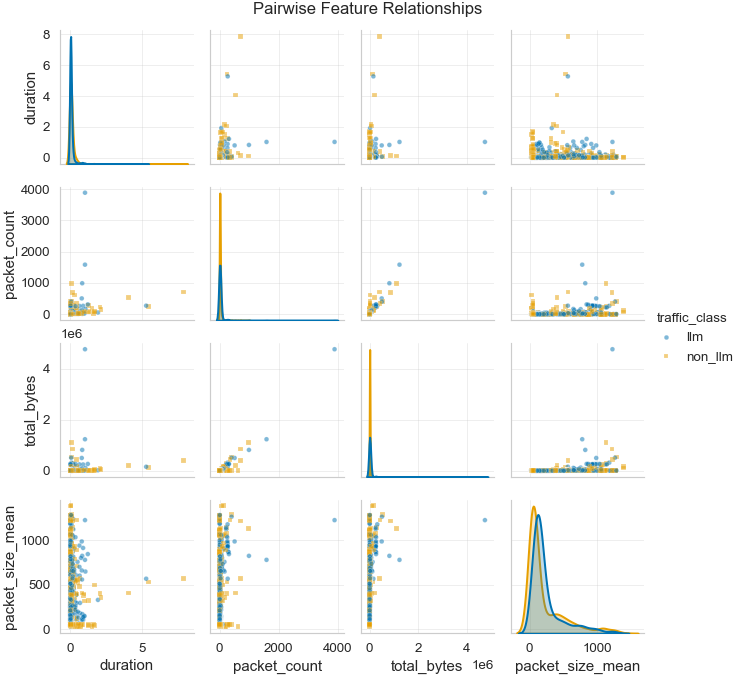

In [28]:
# Pairplot. Each axis off the diagonal is a small scatter — at column-width
# rendering size these are already cramped, so we set a small marker size
# and rely on Okabe-Ito's blue/orange contrast plus distinct marker shapes
# (style="traffic_class") for redundant encoding.
pair_cols = ["duration", "packet_count", "total_bytes", "packet_size_mean", "traffic_class"]
sample = df[pair_cols].dropna()
if len(sample) > 2000:
    sample = sample.sample(2000, random_state=42)

g = sns.pairplot(
    sample, hue="traffic_class",
    palette=cb_palette(sample["traffic_class"].nunique()),
    diag_kind="kde",
    markers=MARKERS[:sample["traffic_class"].nunique()],
    plot_kws={"alpha": 0.5, "s": 8, "edgecolor": "white", "linewidth": 0.2},
    diag_kws={"linewidth": 1.2},
    height=1.4, aspect=1.0,
)
g.figure.suptitle("Pairwise Feature Relationships", y=1.02)
plt.show()


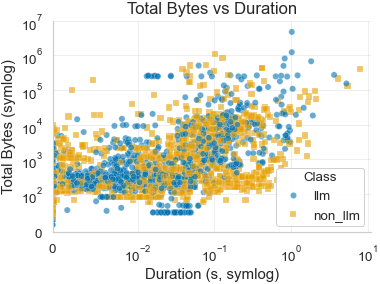

In [29]:
# Scatter: bytes vs duration. Color (Okabe-Ito) + marker shape (style=)
# give two redundant encodings.
fig, ax = plt.subplots(figsize=FIG_HALF)
plot_df = df.dropna(subset=["duration", "total_bytes"])
if len(plot_df) > 3000:
    plot_df = plot_df.sample(3000, random_state=42)

n = plot_df["traffic_class"].nunique()
sns.scatterplot(
    data=plot_df, x="duration", y="total_bytes",
    hue="traffic_class", style="traffic_class",
    palette=cb_palette(n), markers=MARKERS[:n],
    alpha=0.6, s=14, edgecolor="white", linewidth=0.2, ax=ax,
)
ax.set_xlim(0, 11)
ax.set_ylim(0, 10_000_000)
ax.set_xscale("symlog", linthresh=0.01)
ax.set_yscale("symlog", linthresh=100)
ax.set_title("Total Bytes vs Duration")
ax.set_xlabel("Duration (s, symlog)")
ax.set_ylabel("Total Bytes (symlog)")
ax.legend(title="Class", loc="lower right")
plt.tight_layout()
plt.show()


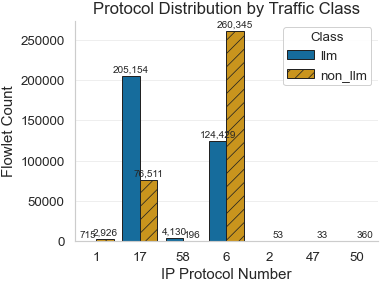

In [30]:
# Protocol distribution by traffic class. Single-column.
proto_df = df.dropna(subset=["protocol"])
proto_counts = (
    proto_df.groupby(["traffic_class", "protocol"])
            .size()
            .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=FIG_HALF)
sns.barplot(
    data=proto_counts, x="protocol", y="count",
    hue="traffic_class",
    palette=cb_palette(proto_counts["traffic_class"].nunique()),
    ax=ax,
)
ax.set_title("Protocol Distribution by Traffic Class")
ax.set_ylabel("Flowlet Count")
ax.set_xlabel("IP Protocol Number")
ax.legend(title="Class", loc="upper right")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", fontsize=6, padding=1)
hatch_by_facecolor(ax)
plt.tight_layout()
plt.show()


In [31]:
# Model-prediction confidence distribution. As with cell 11, hue histograms
# rely on color contrast + step outlines + KDE curve.
pred_df = df.dropna(subset=["model_llm_confidence"])
if not pred_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=FIG_FULL_2PANEL)

    sns.histplot(
        data=pred_df, x="model_llm_confidence", hue="traffic_class",
        palette=cb_palette(pred_df["traffic_class"].nunique()),
        kde=True, stat="density", common_norm=False,
        element="step", linewidth=1.0, alpha=0.35, ax=axes[0],
    )
    axes[0].set_title("Model Confidence Distribution")
    axes[0].set_xlabel("Confidence")

    gt_df = pred_df.dropna(subset=["ground_truth_llm"])
    if not gt_df.empty:
        gt_df = gt_df.copy()
        gt_df["correct"] = gt_df["model_llm_prediction"] == gt_df["ground_truth_llm"]
        sns.histplot(
            data=gt_df, x="model_llm_confidence", hue="correct",
            palette=cb_palette(gt_df["correct"].nunique()),
            kde=True, stat="density", common_norm=False,
            element="step", linewidth=1.0, alpha=0.35, ax=axes[1],
        )
        axes[1].set_title("Confidence by Prediction Correctness")
        axes[1].set_xlabel("Confidence")
    else:
        axes[1].text(0.5, 0.5, "No ground truth labels available",
                     ha="center", va="center", transform=axes[1].transAxes)
        axes[1].set_title("Confidence by Correctness (no ground truth)")

    plt.tight_layout()
    plt.show()
else:
    print("No model predictions found in the database.")


No model predictions found in the database.


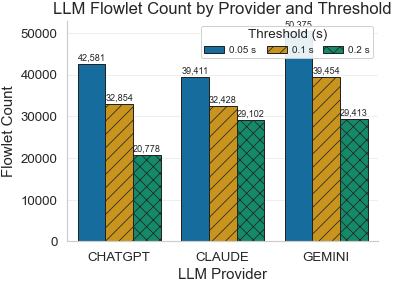

In [32]:
# Per-provider flowlet counts grouped by threshold. Threshold gets the hue
# (it has more entries than provider, so this minimises bar-group width).
if not llm_df.empty:
    llm_thr_local = thr_df[thr_df["traffic_class"] == "llm"]
    if not llm_thr_local.empty:
        llm_thr_counts = (
            llm_thr_local.groupby(["threshold_str", "llm_name"])
                          .size()
                          .reset_index(name="count")
        )

        fig, ax = plt.subplots(figsize=FIG_HALF)
        sns.barplot(
            data=llm_thr_counts, x="llm_name", y="count",
            hue="threshold_str",
            palette=cb_palette(llm_thr_counts["threshold_str"].nunique()),
            ax=ax,
        )
        ax.set_title("LLM Flowlet Count by Provider and Threshold")
        ax.set_ylabel("Flowlet Count")
        ax.set_xlabel("LLM Provider")
        ax.legend(title="Threshold (s)", loc="upper right", ncol=3, fontsize=6)
        for container in ax.containers:
            ax.bar_label(container, fmt="{:,.0f}", fontsize=5.5, padding=1)
        hatch_by_facecolor(ax)
        plt.tight_layout()
        plt.show()
else:
    print("No LLM flowlets for threshold-by-provider analysis.")


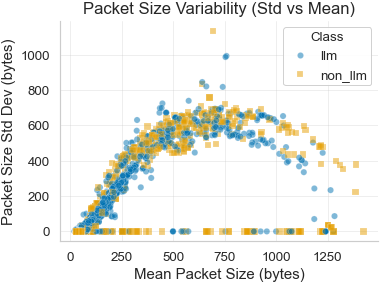

In [33]:
# Scatter: std vs mean of packet size. Color + marker shape redundancy.
fig, ax = plt.subplots(figsize=FIG_HALF)
sz_df = df.dropna(subset=["packet_size_mean", "packet_size_std"])
if len(sz_df) > 3000:
    sz_df = sz_df.sample(3000, random_state=42)

n = sz_df["traffic_class"].nunique()
sns.scatterplot(
    data=sz_df, x="packet_size_mean", y="packet_size_std",
    hue="traffic_class", style="traffic_class",
    palette=cb_palette(n), markers=MARKERS[:n],
    alpha=0.5, s=14, edgecolor="white", linewidth=0.2, ax=ax,
)
ax.set_title("Packet Size Variability (Std vs Mean)")
ax.set_xlabel("Mean Packet Size (bytes)")
ax.set_ylabel("Packet Size Std Dev (bytes)")
ax.legend(title="Class", loc="upper right")
plt.tight_layout()
plt.show()


In [20]:
print("Done — all visualizations rendered.")

Done — all visualizations rendered.
